In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [26]:
models ={
    'Image Backbone': ['../../models/BTSv2_PSonly/stoic-sweep-6'],
    'Oracle-2 Lite': ['../../models/BTSv2-lite/gentle-sweep-1', 
                      '../../models/BTSv2-lite/comfy-smoke-128',
                      '../../models/BTSv2-lite/deft-monkey-129',
                      '../../models/BTSv2-lite/flowing-feather-130',
                      '../../models/BTSv2-lite/stilted-dawn-131'],
    'Oracle-2': ['../../models/BTSv2/peachy-sweep-4',
                 '../../models/BTSv2/rare-night-119', 
                 '../../models/BTSv2/winter-meadow-120', 
                 '../../models/BTSv2/rural-tree-121',
                 '../../models/BTSv2/resilient-feather-125'],
    'Oracle-2 Omni': ['../../models/BTSv2-pro/woven-sweep-9',
                      '../../models/BTSv2-pro/smooth-haze-141',
                      '../../models/BTSv2-pro/splendid-sun-142',
                      '../../models/BTSv2-pro/sweet-glade-143',
                      '../../models/BTSv2-pro/dazzling-thunder-144'],
}

colors = {
    'Oracle-2 Lite': '#994882',
    'Oracle-2': '#008080',
    'Oracle-2 Omni': '#FF6645',
    'Image Backbone': "#000000",
}

markers = {
    'Oracle-2 Lite': 's',
    'Oracle-2': 'D',
    'Oracle-2 Omni': 'o',
    'Image Backbone': '',
}

linestyles = {
    'Oracle-2 Lite': 'solid',
    'Oracle-2': 'solid',
    'Oracle-2 Omni': 'solid',
    'Image Backbone': 'dotted',
}

In [27]:
days = 2**np.arange(0, 11)

In [28]:
def get_data(model_path, c, stat, depth, days=days):

    data = []

    for day in days:

        if model_path in models['Image Backbone']:
            path = f"{model_path}/reports/depth{depth}/report_trigger+1.csv"
        else:
            path = f"{model_path}/reports/depth{depth}/report_trigger+{day}.csv"
        df = pd.read_csv(path)
        df_class = df[df['Class'] == c]
        value = df_class[stat].values[0]
        data.append(value)

    return np.array(data)
        

In [29]:
def get_model_stats(model_name, c, stat, depth, days=days):

    model_paths = models[model_name]
    model_data = np.zeros((len(model_paths), len(days))) 

    for i, model_path in enumerate(model_paths):
        print(f"Processing model: {model_name}, path: {model_path}")
        model_data[i,:] = get_data(model_path, c, stat, depth, days)

    return np.mean(model_data, axis=0), np.std(model_data, axis=0)


In [30]:
def plot_model_stats_multi_level(c, stat):

    # make the plots next to each other for depth in [1, 2]:
    classes = ["Transient", "Persistent", "AGN", "CV", "Varstar", "SN-Ia", "SN-II", "SN-Ib/c", "SLSN"]
    
    fig, axs = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(10, 10))

    # Remove all spacing between subplots
    plt.subplots_adjust(wspace=0, hspace=0)

    for n, c in enumerate(classes):

        i = n // 3
        j = n % 3

        for model_name in models.keys():

            if c == 'Transient' or c == 'Persistent':
                depth = 1
            else: 
                depth = 2

            mean_f1, std_f1 = get_model_stats(model_name, c, stat, depth)

            axs[i, j].plot(days, mean_f1, label=model_name, linestyle=linestyles[model_name], color=colors[model_name], marker=markers[model_name], markeredgecolor='white', markersize=6)
            axs[i, j].fill_between(days, mean_f1 - std_f1, mean_f1 + std_f1, color=colors[model_name], alpha=0.2)

            #axs[i, j].grid(True, which="both", linewidth=0.5, alpha=0.3)
            axs[i, j].set_xscale('log')

        if i != 2:
            axs[i, j].set_xticklabels([])
        else:

            if j == 1:
                axs[i, j].set_xlabel('Days since first detection', fontsize='large')
            axs[i, j].set_xticks(days, labels=days, rotation=60)

        if j != 0:
            pass
            #axs[i, j].set_yticklabels([])
        else:
            if i ==1:
                axs[i, j].set_ylabel(stat, fontsize='large')
        axs[i, j].text(0.8, 0.05, f'{c}', transform=axs[i, j].transAxes, ha='center', fontsize='medium')


        #plt.xticks(days, labels=days)
        # plt.xlabel('Days since first detection', fontsize='xx-large' )
        # plt.ylabel(stat, fontsize='xx-large')
        # plt.title(f'Depth {depth}')

    # Get handles and labels from the last axis to use in the figure legend
    handles, labels = plt.gca().get_legend_handles_labels()

    # Use fig.legend for centering across the whole figure
    fig = plt.gcf()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=len(models), fontsize='x-large')
    
    # Adjust tight_layout to leave room for the legend at the bottom
    plt.tight_layout(rect=[0, 0.02, 1, 1])

    # make a single legend for both plots at the bottom of the whole figure, not just the first plot
    #plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=len(models))
    plt.savefig(f"BTS_F1_per_class.pdf", bbox_inches='tight')
    plt.show()

Processing model: Image Backbone, path: ../../models/BTSv2_PSonly/stoic-sweep-6
Processing model: Oracle-2 Lite, path: ../../models/BTSv2-lite/gentle-sweep-1
Processing model: Oracle-2 Lite, path: ../../models/BTSv2-lite/comfy-smoke-128
Processing model: Oracle-2 Lite, path: ../../models/BTSv2-lite/deft-monkey-129
Processing model: Oracle-2 Lite, path: ../../models/BTSv2-lite/flowing-feather-130
Processing model: Oracle-2 Lite, path: ../../models/BTSv2-lite/stilted-dawn-131
Processing model: Oracle-2, path: ../../models/BTSv2/peachy-sweep-4
Processing model: Oracle-2, path: ../../models/BTSv2/rare-night-119
Processing model: Oracle-2, path: ../../models/BTSv2/winter-meadow-120
Processing model: Oracle-2, path: ../../models/BTSv2/rural-tree-121
Processing model: Oracle-2, path: ../../models/BTSv2/resilient-feather-125
Processing model: Oracle-2 Omni, path: ../../models/BTSv2-pro/woven-sweep-9
Processing model: Oracle-2 Omni, path: ../../models/BTSv2-pro/smooth-haze-141
Processing model:

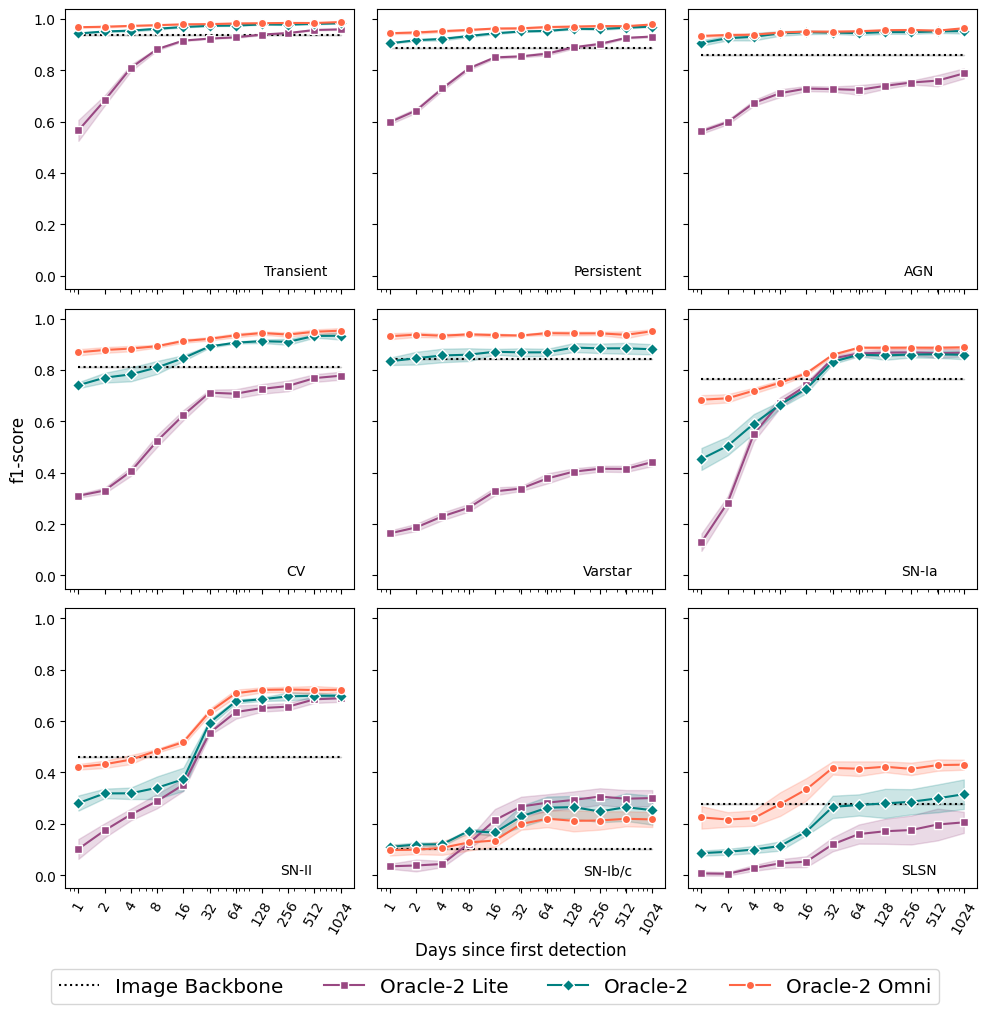

In [31]:
plot_model_stats_multi_level('macro avg', 'f1-score')